In [1]:
# %load_ext autoreload
# %autoreload 2

In [2]:
# for google colab

!pip install pypose
!pip install kornia

In [3]:
# !unzip -q /content/drive/MyDrive/SonarOdometryDataset/aracati2017.zip -d /content/drive/MyDrive/SonarOdometryDataset/a

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
%cd /content/
!git clone https://github.com/MarcinJanis/SonarOdometry.git
%cd SonarOdometry


/content
Cloning into 'SonarOdometry'...
remote: Enumerating objects: 4159, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 4159 (delta 0), reused 0 (delta 0), pack-reused 4152 (from 2)
Receiving objects: 100% (4159/4159), 573.90 MiB | 27.57 MiB/s, done.
Resolving deltas: 100% (1416/1416), done.
/content/SonarOdometry


In [6]:
import os
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F


import numpy as np
import cv2
from scipy.spatial.transform import Rotation as R

from box import Box
import yaml

import matplotlib.pyplot as plt
from tqdm import tqdm

import random
import time

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.evaluation_data_generator import DataGenerator
from src.models.patchifier import Patchifier
from src.data_loader.metrics import eval_metrics_2d


Ate: 1.2061317924511203, expected


In [7]:
# Path to root directory
# root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
root_dir = '/content/SonarOdometry'

# Configuration Files
model_config_pth = os.path.join(root_dir, 'config/model2d.yaml')
sonar_config_pth = os.path.join(root_dir, 'config/sonar_aracati.yaml')

# Path to evaluation dataset
# data_root_dir = os.path.join(root_dir, 'SonarOdometryDataset/supervised/val/seq_14')
# data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample/SonarOdometryDataset_sample/seq_15'
data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/aracati2017/aracati2017'


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
            sonar_config = Box(yaml.safe_load(f))

from src.models.utils import ExtrinsicsCalib
extrinsics_calib = ExtrinsicsCalib(T = [sonar_config.position.x, sonar_config.position.y, sonar_config.position.z],
                                   R = [sonar_config.position.roll, sonar_config.position.pitch, sonar_config.position.yaw])

# Import data generator
# from src.data_loader.transforms import SonarDatasetTranforms

fls_resolution = (model_config.POLAR_FLS_INPUT_HEIGHT, model_config.POLAR_FLS_INPUT_WIDTH) # for own ds
fls_resolution = (model_config.CART_FLS_INPUT_HEIGHT, model_config.CART_FLS_INPUT_WIDTH) # for aracati

data_generator = DataGenerator(data_root_dir, device, fls_resolution=fls_resolution, transforms = None, calibration = extrinsics_calib)
data_lenght = data_generator.get_len()

print(f'Data generator initialized.')
print(f'Data series lenght: {data_lenght}')

# Import model
from src.models.odometry2d import sonar_odometry

Data generator initialized.
Data series lenght: 14436


In [8]:
def visualize_loftr_matches(visu, num_matches=100):

    img = visu['combined_imgs']
    pts1 = visu['pts1']
    pts2 = visu['pts2']
    offset_x = visu['pts2_offset'][1]

    if len(pts1) == 0:
        print("Brak dopasowań do wyświetlenia!")
        return

    n = min(len(pts1), num_matches)
    indices = np.random.choice(len(pts1), n, replace=False)

    fig, ax = plt.subplots(figsize=(14, 7), dpi=120)
    ax.imshow(img)

    for i in indices:
        x1, y1 = pts1[i]
        x2, y2 = pts2[i]

        ax.plot([x1, x2 + offset_x], [y1, y2], color='cyan', linewidth=0.8, alpha=0.5)
        ax.plot(x1, y1, 'ro', markersize=3)
        ax.plot(x2 + offset_x, y2, 'go', markersize=3)

    ax.set_title(f'Matched points ({n}/{len(pts1)} points displayed)')
    ax.axis('off')
    plt.show()


import cv2
import numpy as np
from IPython.display import clear_output
from google.colab.patches import cv2_imshow

def visualize_loftr_matches_cv2(visu, num_matches=100):
    # Kopiujemy obraz, aby nie mazać po oryginalnych danych w pamięci
    img = np.copy(visu['combined_imgs'])
    pts1 = visu['pts1']
    pts2 = visu['pts2']
    offset_x = visu['pts2_offset'][1]

    if len(pts1) == 0:
        print("Brak dopasowań do wyświetlenia!")
        return

    # Upewnienie się, że obraz to uint8 (wymagane przez operacje rysowania OpenCV)
    if img.dtype != np.uint8:
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)

    # Matplotlib używa przestrzeni RGB, OpenCV używa BGR.
    # Konwertujemy, aby kolory nie były odwrócone (np. niebieski z czerwonym)
    if len(img.shape) == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    elif len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    n = min(len(pts1), num_matches)
    indices = np.random.choice(len(pts1), n, replace=False)

    # Rysowanie dopasowań
    for i in indices:
        # OpenCV wymaga współrzędnych jako liczb całkowitych (int)
        x1, y1 = int(pts1[i][0]), int(pts1[i][1])
        x2, y2 = int(pts2[i][0] + offset_x), int(pts2[i][1])

        # Linia (w BGR: Cyan to 255, 255, 0)
        cv2.line(img, (x1, y1), (x2, y2), (255, 255, 0), 1, cv2.LINE_AA)

        # Kropka 1 (w BGR: Czerwony to 0, 0, 255)
        cv2.circle(img, (x1, y1), 3, (0, 0, 255), -1, cv2.LINE_AA)

        # Kropka 2 (w BGR: Zielony to 0, 255, 0)
        cv2.circle(img, (x2, y2), 3, (0, 255, 0), -1, cv2.LINE_AA)

    # Dodanie tekstu informacyjnego w lewym górnym rogu
    text = f'Matched points ({n}/{len(pts1)})'
    cv2.putText(img, text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

    # --- Trik na płynny "czas rzeczywisty" w Colab ---
    clear_output(wait=True)  # Czyści obecne wyjście (komórkę) zaraz przed renderowaniem nowej klatki
    cv2_imshow(img)          # Rysuje nową klatkę

In [12]:
model = sonar_odometry(model_config, sonar_config, device = device,
                       depth_compesation = False,
                       key_frames = True,
                       input_img_format = 'cart',
                       ref_frame_orient = 'aracati')

# seq 0: 0 -> 4811, (4811 samples)
# seq 1: 4811 -> 9622, (4811 samples)
# seq 2: 9624 -> 14435, (4813 samples)

start_idx = 3000
max_iter = 4000
stride = 10

# data containers
gt_xy = []
pred_xy = []

if hasattr(extrinsics_calib, 'se3_s2r') and isinstance(extrinsics_calib.se3_s2r, torch.Tensor) and extrinsics_calib.se3_s2r.device != device:
    extrinsics_calib.se3_s2r = extrinsics_calib.se3_s2r.to(device)
if hasattr(extrinsics_calib, 'se3_r2s') and isinstance(extrinsics_calib.se3_r2s, torch.Tensor) and extrinsics_calib.se3_r2s.device != device:
    extrinsics_calib.se3_r2s = extrinsics_calib.se3_r2s.to(device)


# set initial state
t, frame, pose_gt, depth = data_generator.get_sample(start_idx, return_visu=False, return_depth=True)

# init pose (x, y)
init_pose_gt_np = pose_gt.detach().cpu().numpy()
init_xy = init_pose_gt_np[0:2]
gt_xy.append(init_xy)

# init azimuth
rot = R.from_quat(init_pose_gt_np[3:7])
euler = rot.as_euler('zyx', degrees=False)
init_azimuth = euler[0] # yaw
print(f'Init state: {init_xy}, azimuth: {init_azimuth}')

# Initialize pred_xy with x, y, and initial azimuth to ensure consistent shape
pred_xy.append(np.concatenate((init_xy, np.array([init_azimuth])), axis=-1))

# init frame and mask
mask_pth = os.path.join(data_root_dir,'mask_424x776.png')
mask_np = cv2.imread(mask_pth, 0)
mask_torch = torch.tensor(mask_np, dtype=torch.float, device=device).squeeze(-1).unsqueeze(0)

init_frame = frame.squeeze(1).to(device)
model.set_init_state(init_xy[0], init_xy[1], init_azimuth, init_frame, mask_torch)

# --- Zmienne do śledzenia Klatki Kluczowej (GT) ---
kf_idx = start_idx
kf_pose_gt = init_pose_gt_np
kf_yaw = init_azimuth

# --- main loop ---
for i in tqdm(range(start_idx + stride, start_idx + max_iter, stride), desc="Sonar odometry"):

    t, frame, pose_gt, depth = data_generator.get_sample(i, return_visu=False, return_depth=True)

    # Aktualne GT
    curr_pose_gt = pose_gt.detach().cpu().numpy()
    curr_x, curr_y = curr_pose_gt[0], curr_pose_gt[1]
    rot_curr = R.from_quat(curr_pose_gt[3:7])
    curr_yaw = rot_curr.as_euler('zyx', degrees=False)[0]

    # Predykcja
    pred_pose, pred_azimuth, visu = model(frame.squeeze(1).to(device), depth.to(device), return_visu = True)

    # ---------------------------------------------------------
    # WYLICZANIE OCZEKIWANYCH WARTOŚCI (GT LOCAL TRANSFORMATION)
    # ---------------------------------------------------------
    # Globalna różnica między obecną klatką a obecnym KeyFrame
    dx_gt_global = curr_x - kf_pose_gt[0]
    dy_gt_global = curr_y - kf_pose_gt[1]

    # Różnica kątowa sprowadzona do [-pi, pi]
    dyaw_gt = np.arctan2(np.sin(curr_yaw - kf_yaw), np.cos(curr_yaw - kf_yaw))

    # Transformacja globalnej różnicy (GT) na lokalny układ Klatki Kluczowej (odwrócenie rotacji)
    # tx_gt_local -> ruch w osi X robota (do przodu)
    # ty_gt_local -> ruch w osi Y robota (w lewo)
    tx_gt_local = np.cos(kf_yaw) * dx_gt_global + np.sin(kf_yaw) * dy_gt_global
    ty_gt_local = -np.sin(kf_yaw) * dx_gt_global + np.cos(kf_yaw) * dy_gt_global

    # Składowe predykcji
    pred_tx, pred_ty, pred_dyaw = visu['tx_mapped'], visu['ty_mapped'], visu['theta']
    pred_gx, pred_gy, pred_gyaw = visu['global_pose']

    # --- RYSOWANIE I PRINTY ---
    # visualize_loftr_matches_cv2(visu)  # Odkomentuj jeśli chcesz podgląd

    print(f"\n=======================================================================")
    print(f" Frame matching: [(KF): {kf_idx} ---> Actual: {i}]")
    print(f"=======================================================================")
    print(f"LoFTR matches total: {visu['matches_total']} | confidence: {visu['mean_matched_confidence']:.3f} | RANSAC Inliers: {visu['inliers_abs']} ({visu['inliers_ratio']:.2%})")
    print(f"--- Local transformation ---")
    print(f"  PRED -> tx: {pred_tx:+.5f} m, ty: {pred_ty:+.5f} m, yaw: {pred_dyaw:+.5f} rad")
    print(f"  GT   -> tx: {tx_gt_local:+.5f} m, ty: {ty_gt_local:+.5f} m, yaw: {dyaw_gt:+.5f} rad")
    print(f"  ERR -> tx: {pred_tx-tx_gt_local:+.5f} m, ty: {pred_ty-ty_gt_local:+.5f} m, yaw: {pred_dyaw-dyaw_gt:+.5f} rad")
    print(f"--- Global pose ---")
    print(f"  PRED ->  X: {pred_gx:+.5f},  Y: {pred_gy:+.5f}, Yaw: {pred_gyaw:+.5f}")
    print(f"  GT   ->  X: {curr_x:+.5f},  Y: {curr_y:+.5f}, Yaw: {curr_yaw:+.5f}")

    kf_status = "Actualisation (new kf)" if visu['key_frame_detected'] else "Waiting for kf"
    print(f"--- Keyframe state ---")
    print(f"  Traj from kf: {visu['displacement']:.4f} m, Rot from kf: {visu['azimuth_diff']:.4f} rad -> {kf_status}\n")

    if visu['key_frame_detected']:
        kf_idx = i
        kf_pose_gt = curr_pose_gt
        kf_yaw = curr_yaw

    gt_xy.append(pose_gt[0:2])
    pred_xy.append(np.concatenate((np.array(pred_pose), np.array([pred_azimuth])), axis = -1))

gt_xy_np = np.array(gt_xy)
pred_xy_np = np.array(pred_xy)

# === visualise results ===

# --- metrics ---
ATE, RPE = eval_metrics_2d(pred_xy_np[:,:2], gt_xy_np) # Only compare x,y for ATE/RPE

print('='*50)
print('Metrics')
print(f'Absolute trajectory error: {ATE} [m]')
print(f'Relative pose error: {RPE} [m]')
print('='*50)

# --- trajectory ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

ax.plot(pred_xy_np[:, 0], pred_xy_np[:, 1], label='Predicted', linewidth=2.5, marker='o', markersize=5)
ax.plot(gt_xy_np[:, 0], gt_xy_np[:, 1], label='gt', linewidth=2.5, marker='s', markersize=5)

ax.minorticks_on()
ax.grid(visible=True, which='major', color='#999999', linestyle='-', alpha=0.4)
ax.grid(visible=True, which='minor', color='#cccccc', linestyle='--', alpha=0.2)

ax.set_title('Trajectory prediction', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('X [m]', fontsize=11, labelpad=10)
ax.set_ylabel('Y [m]', fontsize=11, labelpad=10)

ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()

plt.show()

Init state: [-24.196264   0.5     ], azimuth: -3.141592653589793


Sonar odometry:   1%|          | 1/99 [00:00<00:33,  2.92it/s]


 Frame matching: [(KF): 3000 ---> Actual: 3010]
LoFTR matches total: 337 | confidence: 0.471 | RANSAC Inliers: 183 (54.30%)
--- Local transformation ---
  PRED -> tx: -0.01173 m, ty: +0.03070 m, yaw: -0.00074 rad
  GT   -> tx: -0.10593 m, ty: +0.00000 m, yaw: +0.00000 rad
  ERR -> tx: +0.09420 m, ty: +0.03070 m, yaw: -0.00074 rad
--- Global pose ---
  PRED ->  X: -24.18454,  Y: +0.46930, Yaw: +3.14085
  GT   ->  X: -24.09034,  Y: +0.50000, Yaw: -3.14159
--- Keyframe state ---
  Traj from kf: 0.0329 m, Rot from kf: 0.0007 rad -> Waiting for kf



Sonar odometry:   2%|▏         | 2/99 [00:00<00:30,  3.22it/s]


 Frame matching: [(KF): 3000 ---> Actual: 3020]
LoFTR matches total: 202 | confidence: 0.424 | RANSAC Inliers: 71 (35.15%)
--- Local transformation ---
  PRED -> tx: +0.06481 m, ty: +0.00115 m, yaw: -0.00128 rad
  GT   -> tx: -0.21722 m, ty: +0.00000 m, yaw: +0.00000 rad
  ERR -> tx: +0.28203 m, ty: +0.00115 m, yaw: -0.00128 rad
--- Global pose ---
  PRED ->  X: -24.26108,  Y: +0.49885, Yaw: +3.14031
  GT   ->  X: -23.97905,  Y: +0.50000, Yaw: -3.14159
--- Keyframe state ---
  Traj from kf: 0.0648 m, Rot from kf: 0.0013 rad -> Waiting for kf



...

Sonar odometry:  99%|█████████▉| 98/99 [00:30<00:00,  3.12it/s]


 Frame matching: [(KF): 3960 ---> Actual: 3980]
LoFTR matches total: 489 | confidence: 0.528 | RANSAC Inliers: 283 (57.87%)
--- Local transformation ---
  PRED -> tx: -0.79968 m, ty: +0.13748 m, yaw: -0.00382 rad
  GT   -> tx: -0.36056 m, ty: +0.00000 m, yaw: +0.00000 rad
  ERR -> tx: -0.43912 m, ty: +0.13748 m, yaw: -0.00382 rad
--- Global pose ---
  PRED ->  X: -7.85634,  Y: +1.02760, Yaw: -3.03556
  GT   ->  X: -7.31267,  Y: +0.50000, Yaw: -3.14159
--- Keyframe state ---
  Traj from kf: 0.8114 m, Rot from kf: 0.0038 rad -> Waiting for kf



Sonar odometry: 100%|██████████| 99/99 [00:31<00:00,  3.17it/s]


 Frame matching: [(KF): 3960 ---> Actual: 3990]
LoFTR matches total: 423 | confidence: 0.512 | RANSAC Inliers: 237 (56.03%)
--- Local transformation ---
  PRED -> tx: -1.08135 m, ty: -0.05921 m, yaw: +0.00189 rad
  GT   -> tx: -0.59068 m, ty: +0.00000 m, yaw: +0.00000 rad
  ERR -> tx: -0.49067 m, ty: -0.05921 m, yaw: +0.00189 rad
--- Global pose ---
  PRED ->  X: -7.59792,  Y: +1.25398, Yaw: -3.02985
  GT   ->  X: -7.08255,  Y: +0.50000, Yaw: -3.14159
--- Keyframe state ---
  Traj from kf: 1.0830 m, Rot from kf: 0.0019 rad -> Actualisation (new kf)



TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

Metrics
Absolute trajectory error: 4.378812196841563 [m]
Relative pose error: 0.27017680346409945 [m]


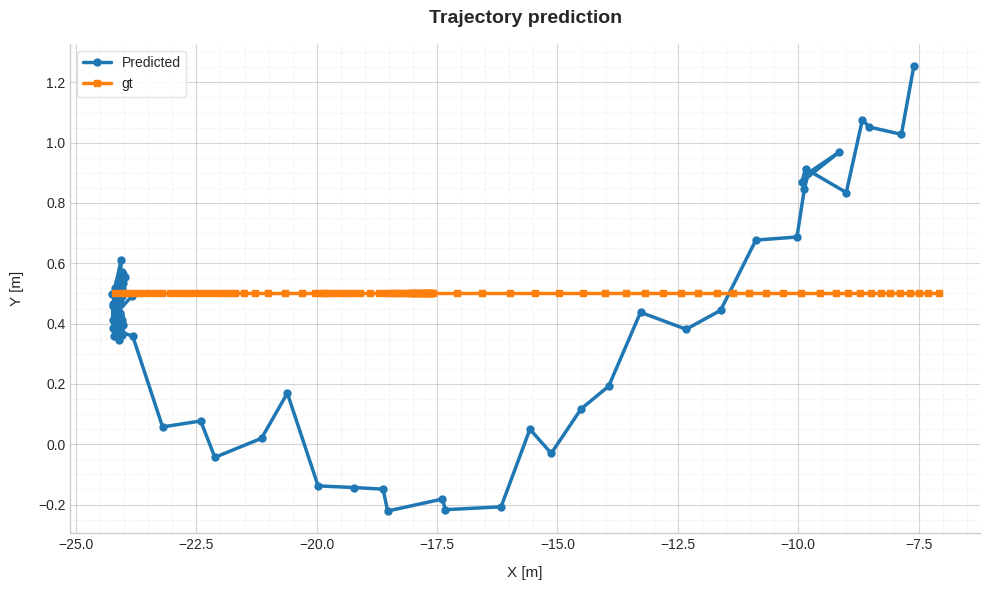

In [14]:


gt_xy_np = np.array([item.cpu().numpy() if isinstance(item, torch.Tensor) else item for item in gt_xy])
pred_xy_np = np.array(pred_xy)

# === visualise results ===

# --- metrics ---
ATE, RPE = eval_metrics_2d(pred_xy_np[:,:2], gt_xy_np) # Only compare x,y for ATE/RPE

print('='*50)
print('Metrics')
print(f'Absolute trajectory error: {ATE} [m]')
print(f'Relative pose error: {RPE} [m]')
print('='*50)

# --- trajectory ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

ax.plot(pred_xy_np[:, 0], pred_xy_np[:, 1], label='Predicted', linewidth=2.5, marker='o', markersize=5)
ax.plot(gt_xy_np[:, 0], gt_xy_np[:, 1], label='gt', linewidth=2.5, marker='s', markersize=5)

ax.minorticks_on()
ax.grid(visible=True, which='major', color='#999999', linestyle='-', alpha=0.4)
ax.grid(visible=True, which='minor', color='#cccccc', linestyle='--', alpha=0.2)

ax.set_title('Trajectory prediction', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('X [m]', fontsize=11, labelpad=10)
ax.set_ylabel('Y [m]', fontsize=11, labelpad=10)

ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()

plt.show()

In [ ]:
print('--- Data Generator Sample Check ---')
for i in range(start_idx, start_idx + min(max_iter, 5), stride): # Check first 5 samples
    t_check, frame_check, pose_gt_check, depth_check = data_generator.get_sample(i, return_visu=False, return_depth=True)
    print(f"Iteration {i}:")
    print(f"  t type: {type(t_check)}, shape: {t_check.shape if hasattr(t_check, 'shape') else 'N/A'}")
    print(f"  frame type: {type(frame_check)}, shape: {frame_check.shape}")
    print(f"  pose_gt type: {type(pose_gt_check)}, shape: {pose_gt_check.shape}")
    print(f"  depth type: {type(depth_check)}, shape: {depth_check.shape}")
print('--- End Data Generator Sample Check ---')

In [ ]:

# --- trajectory ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

ax.plot(pred_xy_np[:, 0], pred_xy_np[:, 1], label='Predicted', linewidth=2.5, marker='o', markersize=5)
ax.plot(gt_xy_np[:, 0], gt_xy_np[:, 1], label='gt', linewidth=2.5, marker='s', markersize=5)

ax.minorticks_on()
ax.grid(visible=True, which='major', color='#999999', linestyle='-', alpha=0.4)
ax.grid(visible=True, which='minor', color='#cccccc', linestyle='--', alpha=0.2)

ax.set_title('Trajectory prediction', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('X [m]', fontsize=11, labelpad=10)
ax.set_ylabel('Y [m]', fontsize=11, labelpad=10)

ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()

plt.show()

In [ ]:

import csv

n = pred_xy_np.shape[0]
filename = os.path.join(data_root_dir, 'pred.csv')

with open(filename, mode='w', newline='') as file:
  writer = csv.writer(file)

  writer.writerow(['timestamp', 'x', 'y', 'z', 'q_x', 'q_y', 'q_z', 'q_w'])

  for i in range(n):

      timestamp = i + 1

      x = pred_xy_np[i, 0]
      y = pred_xy_np[i, 1]
      z = 0.0
      theta = pred_xy_np[i, 2]

      q_x = 0.0
      q_y = 0.0
      q_z = np.sin(theta / 2.0)
      q_w = np.cos(theta / 2.0)

      writer.writerow([timestamp, x, y, z, q_x, q_y, q_z, q_w])

  print(f"Saved {n} frames to file: {filename}")